# Olist Brazilian E-commerce — a delivery-quality analysis

**Question this notebook answers:** the Olist marketplace (~100k orders, Sept 2016 – Oct 2018)
lets customers rate every order 1–5. What actually drives those ratings, what is it
costing the business, and what should the platform do differently?

**Stack.** DuckDB is the engine. Every piece of data work is a commented `.sql` file in
[`sql/`](../sql); this notebook only runs those files and draws the charts. The SQL is
printed above each result so it can be read in place.

**Structure.** Data quality first (the dataset is genuinely messy), then six business
questions, then limitations. Each question ends with a number and a decision.

In [1]:
import sys; sys.path.insert(0, "..")
import pandas as pd
from IPython.display import Image
from src.queries import run_sql_file, sql_text
from src import plots

plots.apply_style()
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

def show(name):
    "Print the SQL file, run it, return the result DataFrame."
    print(sql_text(name))
    return run_sql_file(name)

def chart(path):
    "Display a figure that a plots.* function just wrote."
    return Image(str(path))

---
## 0. Data quality

The cleaning lives in one place — [`sql/00_staging.sql`](../sql/00_staging.sql) — which
builds a set of `stg_*` views the analysis queries read from. Every decision below is
applied there, not scattered through the analysis.

| Issue found | Size | Decision |
|---|---|---|
| `order_reviews` has duplicate rows per order | 547 order_ids with >1 review; `review_id` reused across 789 rows | keep one row per order — the most recent by `review_answer_timestamp` |
| Orders marked `delivered` with no delivery date | 8 | excluded from delivery analysis (`is_clean_delivered` flag) |
| Delivery timestamp before purchase timestamp | 0 in this snapshot | flag kept in staging in case a refresh introduces them |
| `order_approved_at` missing | 160 | not used as a filter; noted where relevant |
| Orders with no review at all | 768 (0.8%) | excluded from score analysis; response bias checked in Q3 |
| Portuguese category names | 71-row translation table; 2 categories missing from it; 610 products with no category | translated in staging; unmatched → `'unknown'` (1,603 order-items) |
| `geolocation`: many GPS points per zip prefix, some off-continent | 42 rows outside Brazil's bounding box | collapse to the **median** lat/lng per zip prefix, Brazil bbox only |
| Customer / seller zip prefix absent from geolocation | 279 customers, 7 sellers | dropped from the distance analysis only (Q6), ~0.3% |
| 2016 data | Sept 2016: 2 orders, Oct: 290, Dec: 1 | a pilot — flagged `is_partial_month`, excluded from trend/seasonality |

Run the diagnostics:

In [2]:
from src.db import get_connection
con = get_connection()

checks = {
 "orders, total": "SELECT count(*) FROM olist_orders_dataset",
 "orders, status = delivered": "SELECT count(*) FROM olist_orders_dataset WHERE order_status='delivered'",
 "clean delivered (usable for delivery analysis)": "SELECT count(*) FROM stg_orders WHERE is_clean_delivered",
 "delivered but no delivery date": "SELECT count(*) FROM olist_orders_dataset WHERE order_status='delivered' AND order_delivered_customer_date IS NULL",
 "delivery date before purchase": "SELECT count(*) FROM olist_orders_dataset WHERE order_delivered_customer_date < order_purchase_timestamp",
 "order_ids with >1 review row": "SELECT count(*) FROM (SELECT order_id FROM olist_order_reviews_dataset GROUP BY 1 HAVING count(*)>1)",
 "orders with no review": "SELECT count(*) FROM olist_orders_dataset o LEFT JOIN (SELECT DISTINCT order_id FROM olist_order_reviews_dataset) r USING(order_id) WHERE r.order_id IS NULL",
 "order-items mapped to 'unknown' category": "SELECT count(*) FROM stg_order_items WHERE category='unknown'",
 "geolocation rows outside Brazil bbox": "SELECT count(*) FROM olist_geolocation_dataset WHERE NOT (geolocation_lat BETWEEN -34 AND 6 AND geolocation_lng BETWEEN -74 AND -34)",
}
pd.DataFrame(
    [(k, con.execute(v).fetchone()[0]) for k, v in checks.items()],
    columns=["check", "n"],
)

,check,n
0,"orders, total",99441
1,"orders, status = delivered",96478
2,clean delivered (usable for delivery analysis),96470
3,delivered but no delivery date,8
4,delivery date before purchase,0
5,order_ids with >1 review row,547
6,orders with no review,768
7,order-items mapped to 'unknown' category,1603
8,geolocation rows outside Brazil bbox,42


---
## Q1. Does delivery time predict review score? Is it linear, or is there a threshold?

Two framings: absolute transit time, and time **relative to the delivery date the
customer was promised at checkout** (`order_estimated_delivery_date`).

In [3]:
q1 = show("01_delivery_time_vs_review"); q1

-- ============================================================================
-- 01_delivery_time_vs_review.sql
--
-- BUSINESS QUESTION
--   Does how long an order takes to arrive predict the review score the
--   customer leaves? How big is the effect, and is it linear or is there a
--   point where satisfaction falls off a cliff?
--
-- WHY IT MATTERS
--   Delivery speed is one of the few post-purchase levers a marketplace
--   actually controls. If satisfaction degrades smoothly, "ship a bit faster
--   everywhere" is the play. If it collapses past a threshold, the money is
--   in killing the tail of very-late orders, not in shaving the average.
--
-- WHAT THIS QUERY RETURNS
--   One row per delivery-time bucket:
--     orders                 - sample size (watch the small tail buckets)
--     mean_review_score      - average of the 1-5 score
--     pct_one_star           - share of 1-star reviews  <- the "collapse" signal
--     pct_five_star          - share of 5-star reviews
--

,delivery_bucket,orders,mean_review_score,pct_one_star,pct_five_star,median_days_in_bucket
0,00-03 days,6926,4.463,0.050,0.710,2.0
1,04-07 days,23624,4.398,0.055,0.673,6.0
2,08-11 days,24305,4.325,0.063,0.638,9.0
3,12-15 days,16771,4.244,0.072,0.599,13.0
4,16-20 days,11249,4.107,0.089,0.544,18.0
5,21-30 days,8769,3.620,0.183,0.410,24.0
6,31-45 days,3189,2.337,0.517,0.179,35.0
7,46+ days,991,1.773,0.694,0.090,53.0


In [4]:
q1_stats = show("01_delivery_time_vs_review_stats"); q1_stats

-- ============================================================================
-- 01_delivery_time_vs_review_stats.sql
--
-- Companion to 01_delivery_time_vs_review.sql. Collapses the whole
-- relationship to a few numbers so the README can state the effect size.
--
--   n_orders                clean delivered orders with a review
--   pearson_r               correlation of review_score with delivery_days
--                           (negative = slower delivery, lower score)
--   score_lost_per_week     OLS slope * 7  -> review points lost per extra
--                           week in transit, holding nothing else constant
--   intercept               modelled score at 0 days (context only)
--   mean_score              baseline average score
--
-- This is a descriptive association, not a causal estimate. Late deliveries
-- correlate with damaged goods, remote regions, unreliable sellers, etc.
-- Treated honestly as such in the README > Limitations.
-- ================================

,n_orders,pearson_r,score_lost_per_week,intercept,mean_score
0,95824,-0.334,-0.317,4.72,4.156


  wrote q1_delivery_buckets.png


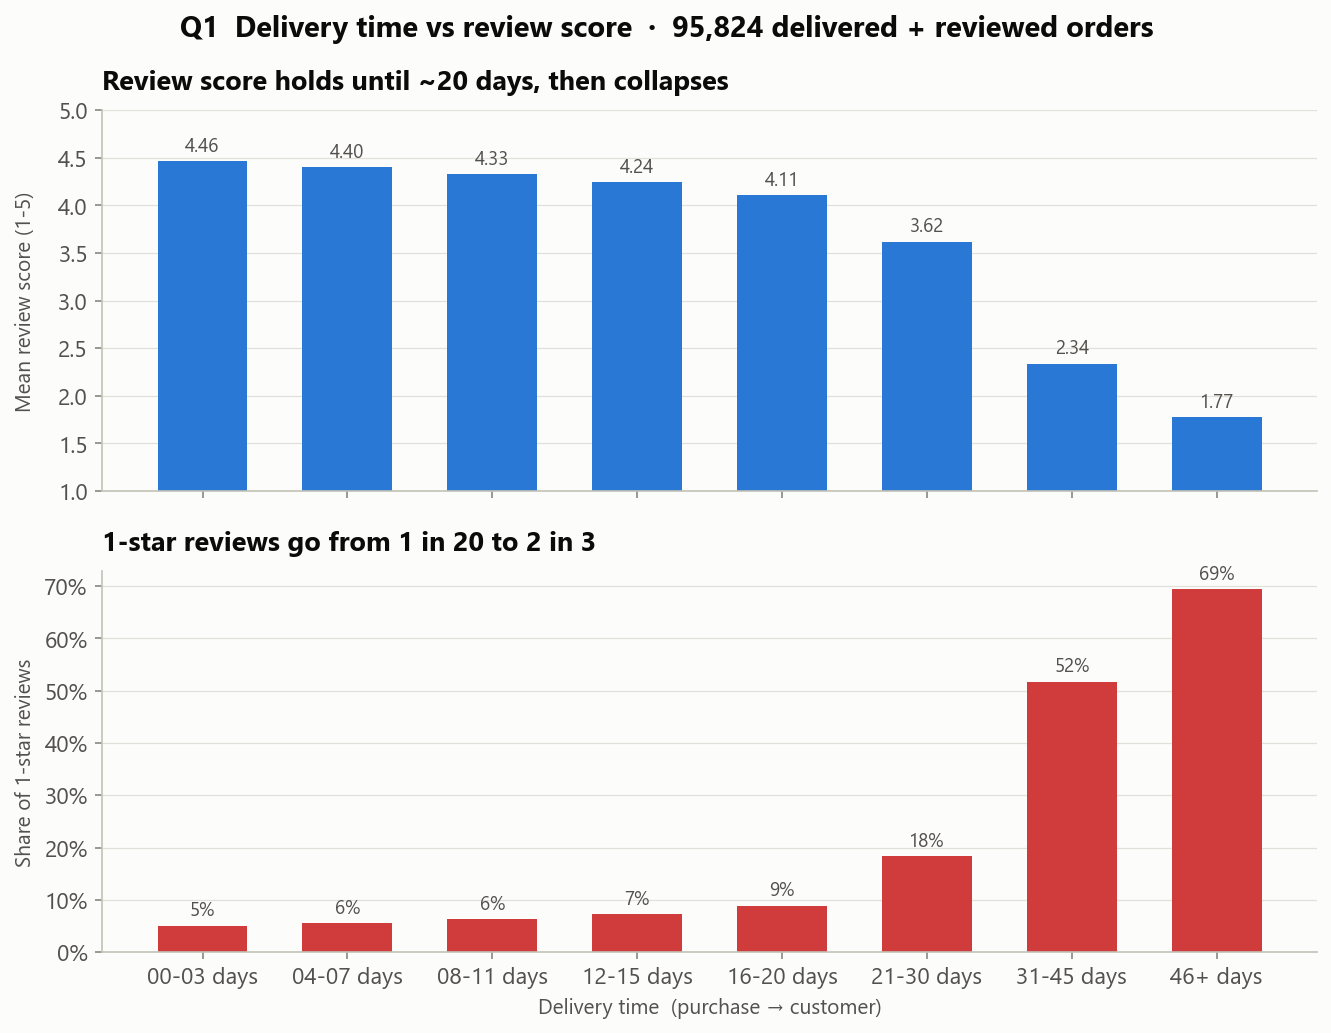

In [5]:
chart(plots.plot_q1_delivery_buckets(q1))

In [6]:
q1_late = show("01_delivery_time_vs_review_by_lateness"); q1_late

-- ============================================================================
-- 01_delivery_time_vs_review_by_lateness.sql
--
-- Re-frames question 1 the way the customer actually experiences it: not
-- "how many days did it take" but "how did it land against the delivery date
-- I was promised at checkout".
--
-- order_estimated_delivery_date is shown to the customer before they buy, so
-- days_late = actual - estimate is the expectation gap. This is usually where
-- the threshold shows up: customers forgive a slow-but-on-time delivery and
-- punish a broken promise.
--
-- RETURNS one row per expectation-gap band:
--   orders, mean_review_score, pct_one_star
--
-- DATA QUALITY: same is_clean_delivered filter as 01_..., plus estimated date
-- must be present (it always is in practice).
-- ============================================================================

WITH d AS (
    SELECT
        date_diff('day',
                  o.order_estimated_delivery_date,
                  o.

,vs_promised_date,orders,mean_review_score,pct_one_star
0,a) 10+ days early,61523,4.323,0.064
1,b) 1-9 days early,26640,4.226,0.070
2,c) on the promised day,1280,4.034,0.085
3,d) 1-5 days late,2722,2.988,0.336
4,e) 6-10 days late,1634,1.771,0.679
5,f) 11+ days late,2025,1.709,0.695


  wrote q1_lateness.png


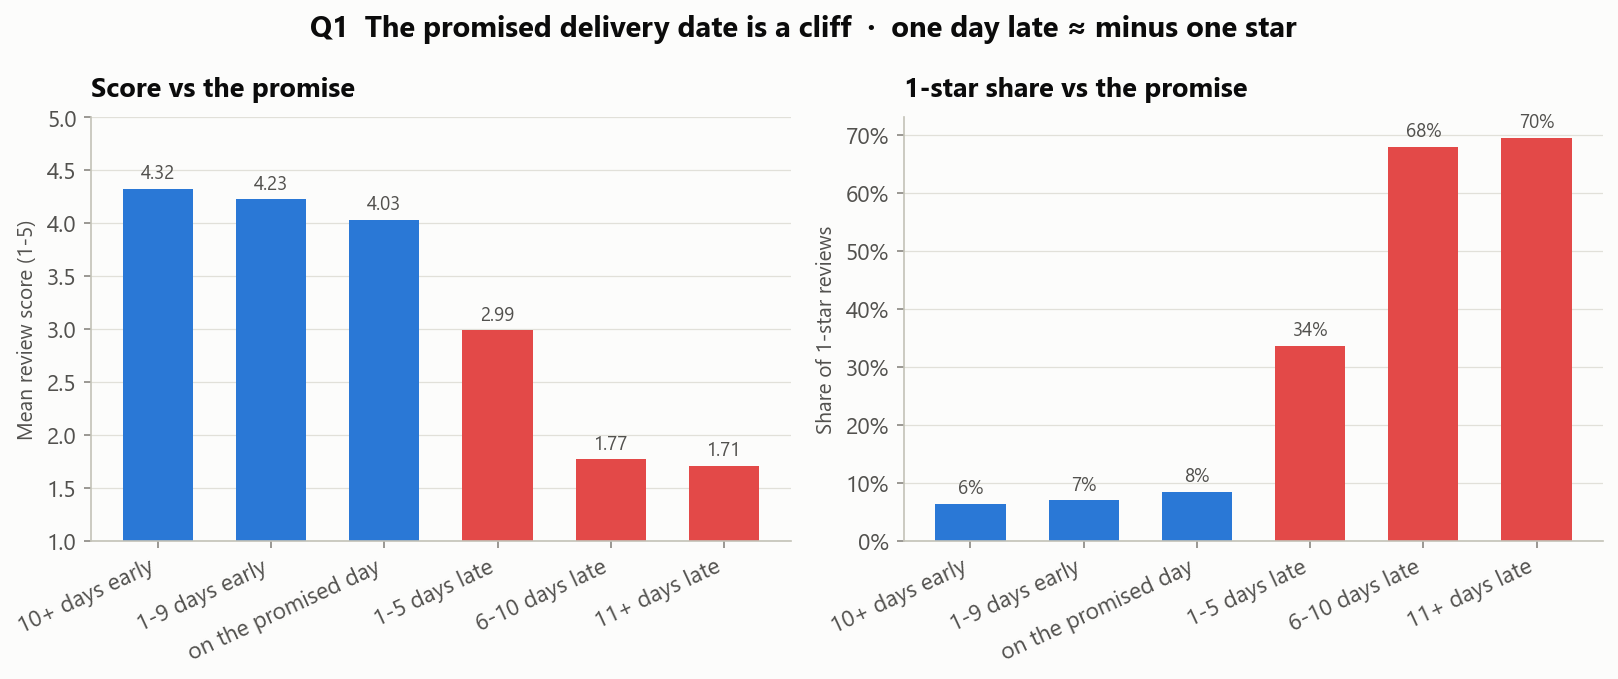

In [7]:
chart(plots.plot_q1_lateness(q1_late))

**Number.** Pearson *r* between delivery days and review score is **−0.33**; the fitted
slope is about **−0.3 review points for every extra week** in transit. But the average
hides a threshold. Mean score is basically flat (4.5 → 4.1) out to ~20 days, then falls
off a cliff: **3.6 at 21–30 days, 2.3 at 31–45, 1.8 beyond 45**. The 1-star share goes
from 1-in-20 to **2-in-3**.

Against the *promise* the cliff is sharper and it sits exactly at the promised date.
Early or on-time orders average ~4.0–4.3. **One-to-five days late: 2.99. Six-to-ten days
late: 1.77**, with 68% one-star. Beating the estimate by 10+ days is worth only ~0.1
points over beating it by a day — there is no upside to being very early.

**Decision.** Treat *"this order will miss its promised date"* as a sev-1 operational
trigger — intervene, re-notify, or pre-emptively compensate **before** the date passes,
not after the bad review lands. Do not spend on shaving days off already-on-time orders;
spend on the late tail. The estimate is an expectation anchor, so keep padding it (Q6
shows Olist already does) rather than quoting an aggressive date it might miss.

---
## Q2. Which categories deliver worst against their promise, and what does it cost?

In [8]:
q2 = show("02_category_delivery_performance"); q2.head(15)

-- ============================================================================
-- 02_category_delivery_performance.sql
--
-- BUSINESS QUESTION
--   Which product categories deliver worst against the date the customer was
--   promised, and what does that lateness cost in review scores?
--
-- WHY IT MATTERS
--   The estimated delivery date is a promise the platform sets. Categories
--   that systematically break it are a targeted fix: renegotiate carrier SLAs,
--   pad the estimate, or restrict which sellers can list in that category.
--   Ranking by "days late vs the promise" (not raw transit time) isolates the
--   broken-promise problem from categories that are just far away.
--
-- WHAT THIS QUERY RETURNS  (one row per category, >= 200 delivered orders,
--   ordered by pct_late DESC - "worst against the promise" first)
--   orders                       - sample size
--   pct_late                     - share delivered after the promised date
--   avg_days_vs_estimate         - mean(a

,category,orders,pct_late,avg_days_vs_estimate,avg_review_score,score_when_on_time,score_when_late,score_gap_late_vs_ontime,score_points_lost_per_order,score_points_lost_total
0,audio,345,0.128,-10.06,3.841,4.113,1.977,2.136,0.273,94.0
1,books_technical,255,0.110,-11.28,4.427,4.529,3.607,0.922,0.101,26.0
2,home_confort,390,0.105,-9.76,3.885,4.049,2.488,1.561,0.164,64.0
3,electronics,2498,0.098,-11.03,4.124,4.274,2.751,1.523,0.149,373.0
4,food,437,0.098,-9.85,4.327,4.447,3.233,1.214,0.119,52.0
5,construction_tools_lights,239,0.092,-11.51,4.151,4.272,2.955,1.317,0.121,29.0
6,baby,2787,0.090,-11.59,4.103,4.278,2.335,1.943,0.175,487.0
7,office_furniture,1244,0.090,-11.87,3.645,3.752,2.563,1.189,0.107,133.0
8,unknown,1382,0.090,-11.40,4.011,4.168,2.419,1.749,0.157,218.0
9,musical_instruments,605,0.089,-11.46,4.235,4.436,2.185,2.251,0.200,121.0


  wrote q2_category_late.png


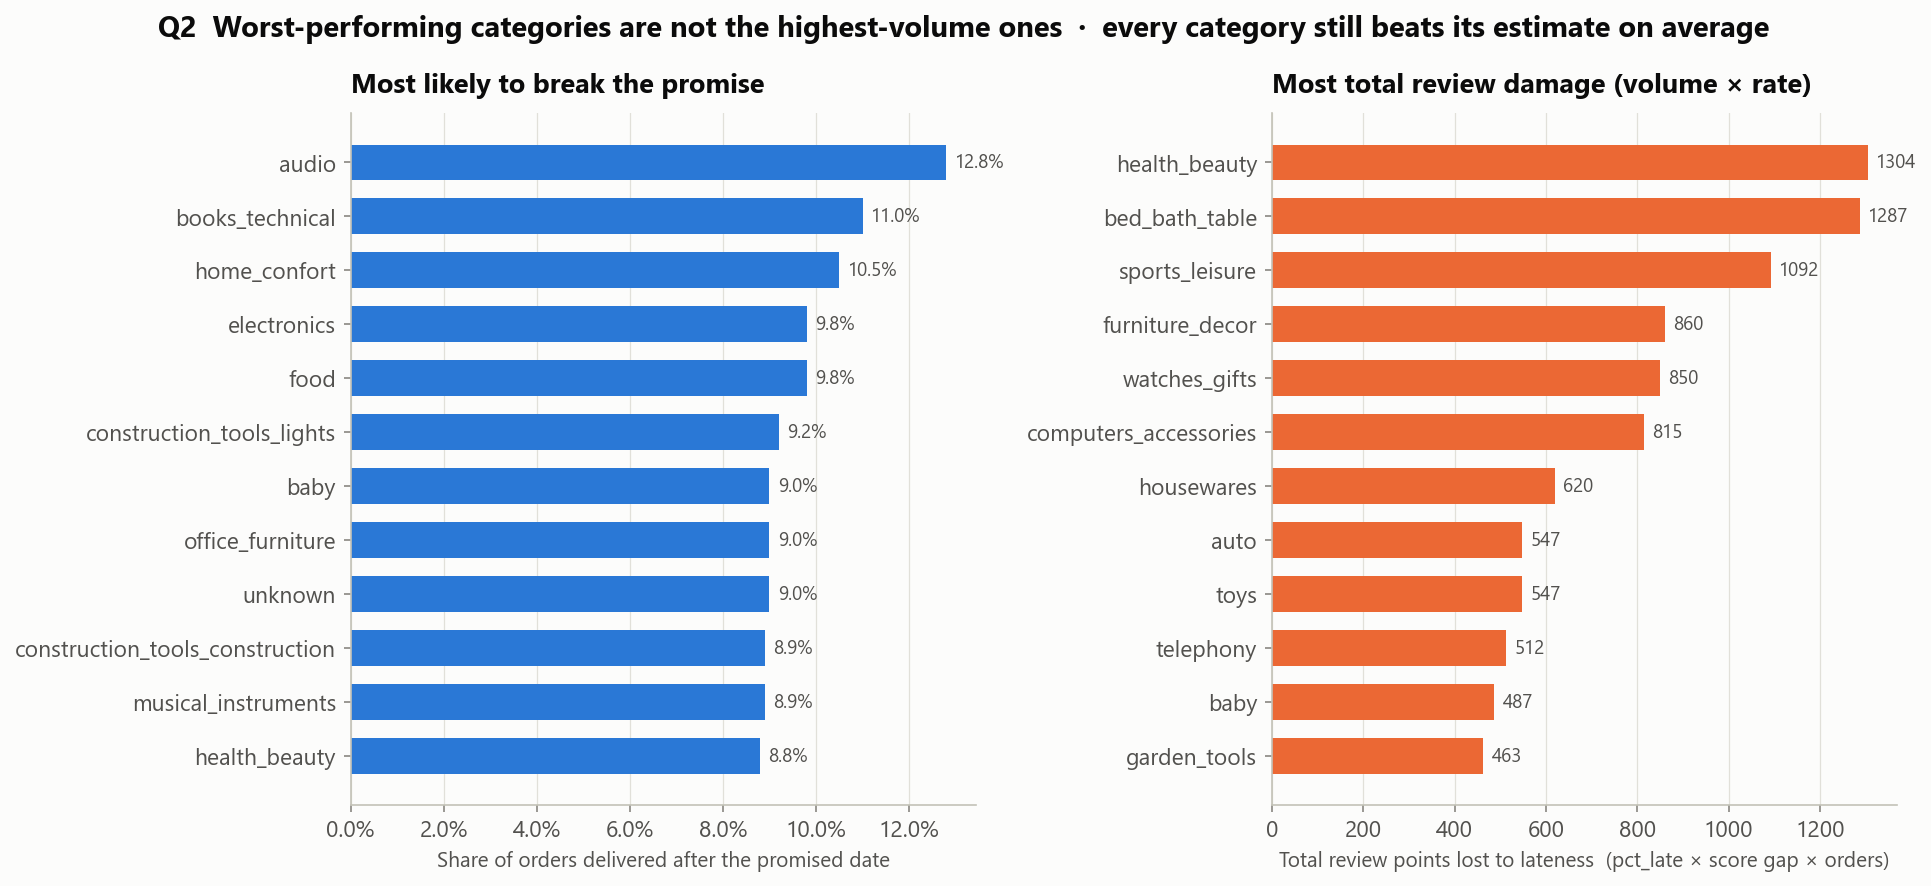

In [9]:
chart(plots.plot_q2_category_late(q2))

**Number.** Every one of the 43 categories with a usable sample **beats** its estimated
delivery date on average (by 10–15 days) — so this is a tail problem, not a
broken-average problem. Ranked by how often the promise breaks: **audio (12.8% late),
books_technical (11.0%), home_confort (10.5%), electronics (9.8%), food (9.8%)**. Within
a category, a late delivery costs **1.2 to 2.1 review points** versus an on-time one
(`audio` loses 2.1).

The categories doing the most *total* review damage are different — they are the
high-volume ones: **health & beauty (~1,300 review points lost), bed/bath/table
(~1,290), sports & leisure (~1,090)**. Same ~8% late rate as the marketplace, but on
6,000–9,000 orders.

**Decision.** Two separate actions. (1) For `audio`, `electronics` and the home
categories — above-average late rates *and* high punishment when late — widen the
displayed estimate by a week or audit their carrier lanes specifically. (2) For
health/beauty and bed/bath — the volume categories — a 1-point improvement in the late
rate is worth more than fixing any single small category outright; make them the target
for the Q1 "before the date passes" intervention.

---
## Q3. What fraction of customers ever order twice? Does a bad first order predict churn?

In [10]:
q3 = show("03_repeat_customers"); q3

-- ============================================================================
-- 03_repeat_customers.sql
--
-- BUSINESS QUESTION
--   What fraction of customers ever place a second order? What does the
--   marketplace's retention actually look like?
--
-- WHY IT MATTERS
--   Acquisition cost only pays back if customers come back. If repeat rate is
--   near zero the business is a one-shot acquisition machine and the whole
--   growth model (and the value of fixing delivery) has to be argued on first
--   orders alone, not lifetime value.
--
-- WHAT THIS QUERY RETURNS  (one row)
--   customers                 - distinct real people (customer_unique_id)
--   pct_ordering_2plus        - fraction with >= 2 non-cancelled orders
--   pct_ordering_3plus        - fraction with >= 3
--   mean_orders_per_customer
--   max_orders                - the single most active customer
--
-- DATA-QUALITY DECISIONS
--   * customer_unique_id, not customer_id: Olist mints a fresh customer_id per
--     o

,customers,pct_ordering_2plus,pct_ordering_3plus,mean_orders_per_customer,max_orders
0,95560,0.0306,0.0025,1.0341,17


In [11]:
q3_fr = show("03_repeat_customers_by_first_review"); q3_fr

-- ============================================================================
-- 03_repeat_customers_by_first_review.sql
--
-- BUSINESS QUESTION
--   Does a bad first experience predict never coming back? Split the return
--   rate by the review score the customer left on their first order.
--
-- WHY IT MATTERS
--   If 1-star first-timers return at half the rate of 5-star first-timers,
--   then a botched first delivery is not just one bad review - it is a lost
--   customer, and the delivery investment pays for itself through retention.
--   If the return rate is flat across scores, retention is driven by something
--   else and delivery should be justified on reviews / word-of-mouth alone.
--
-- WHAT THIS QUERY RETURNS  (one row per first-order review score, plus NULL)
--   first_review_score   - 1..5, or NULL = first order never reviewed
--   customers            - how many people started here
--   pct_returned         - fraction that placed a 2nd order within the window
--   pct_

,first_review_score,customers,pct_returned,pct_returned_120d
0,NaN,596,0.0403,0.0285
1,1.0,8681,0.0343,0.0275
2,2.0,2393,0.0313,0.0238
3,3.0,6138,0.0344,0.0259
4,4.0,14054,0.0332,0.0226
5,5.0,40218,0.0391,0.0271


  wrote q3_repeat.png


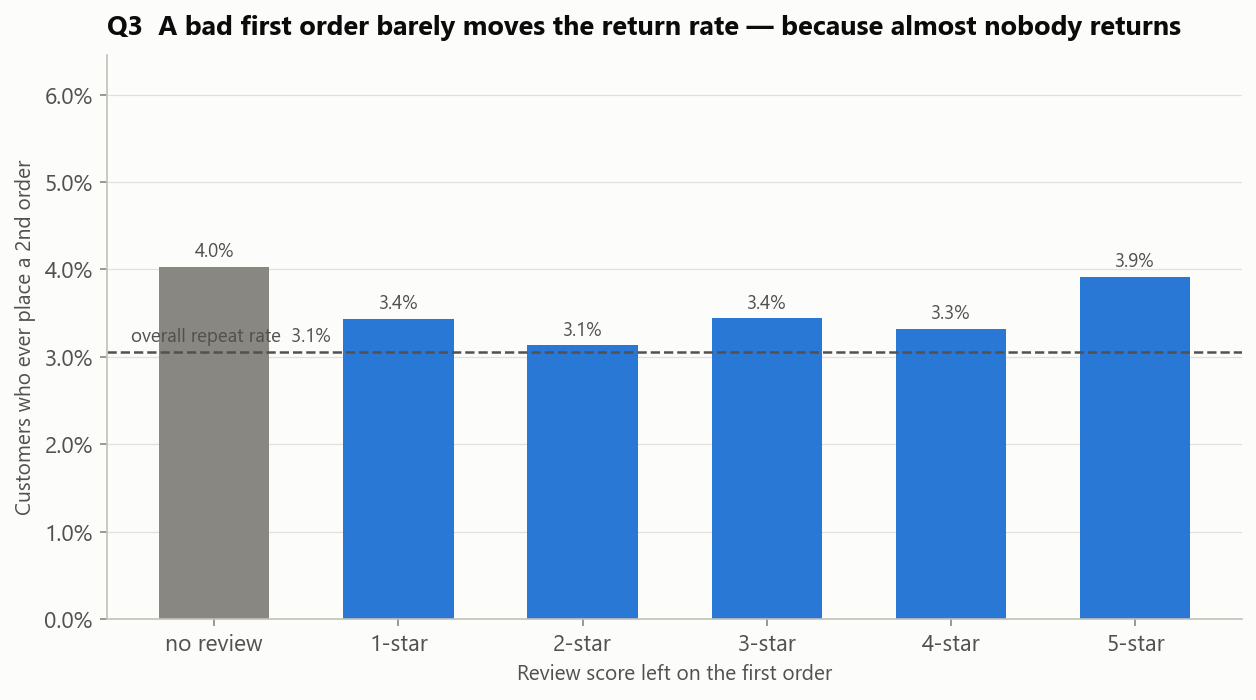

In [12]:
repeat_rate = float(q3["pct_ordering_2plus"].iloc[0])
chart(plots.plot_q3_repeat(q3_fr, repeat_rate))

**Number.** **3.1% of customers ever place a second order.** 0.25% place a third. Mean
lifetime orders per customer: 1.03.

Splitting the return rate by the score left on the first order (restricted to first
orders old enough to have a fair 120-day window): **1-star first-timers return at 3.4%,
5-star at 3.9%.** A half-point spread. A bad first experience barely moves the needle —
because *nobody's* needle moves. Customers who never reviewed return at 4.0%, so review
non-response is not hiding a churned-angry segment either.

**Decision.** In this period Olist is structurally a **single-purchase marketplace**. The
entire ROI case for delivery quality has to be built on first-order economics — reviews,
platform reputation, star ratings that feed search rank — not on lifetime value or
retention, because there is almost none to protect. Do **not** budget a loyalty/CRM
programme as if LTV multiples exist. (Caveat in Limitations: heavy end-of-window
censoring, and customers may not perceive "Olist" as the brand.)

---
## Q4. Seller segmentation — who to invest in, who to drop?

Segments by volume, **shipping reliability** (handover to the carrier by
`shipping_limit_date` — the part the seller controls) and review score. Rules are in
[`sql/04_seller_segmentation.sql`](../sql/04_seller_segmentation.sql).

In [13]:
q4 = show("04_seller_segmentation"); q4

-- ============================================================================
-- 04_seller_segmentation.sql
--
-- BUSINESS QUESTION
--   Group the ~3,000 sellers by volume, delivery reliability and review
--   performance. Which segment should the platform invest in, and which is
--   dragging the marketplace down?
--
-- WHY IT MATTERS
--   Seller quality is uneven and the platform can act on it: onboarding
--   support, better placement, or delisting. This needs segments tied to a
--   decision, not a leaderboard.
--
-- SEGMENT RULES  (applied per seller, first match wins)
--   Core - invest         >= 50 orders, <= 10% shipped late, avg review >= 4.0
--   Rising - grow          < 50 orders, <= 10% shipped late, avg review >= 4.0
--   At risk - fix or drop  avg review < 3.5  OR  > 25% shipped late
--   Steady - maintain      everyone else
--
--   "Shipped late" = handed to the carrier after shipping_limit_date. That is
--   the seller's own SLA; carrier transit time is not the selle

,segment,sellers,orders,gmv,pct_of_gmv,avg_pct_shipped_late,avg_review_score,avg_days_vs_estimate
0,Core - invest,233,39876.0,5003819.0,36.8,0.031,4.27,-12.73
1,Steady - maintain,627,36028.0,4471378.0,32.9,0.105,3.97,-12.00
2,Rising - grow,1411,13135.0,2280833.0,16.8,0.008,4.57,-13.59
3,At risk - fix or drop,824,10971.0,1835613.0,13.5,0.386,2.96,-9.51


  wrote q4_seller_segments.png


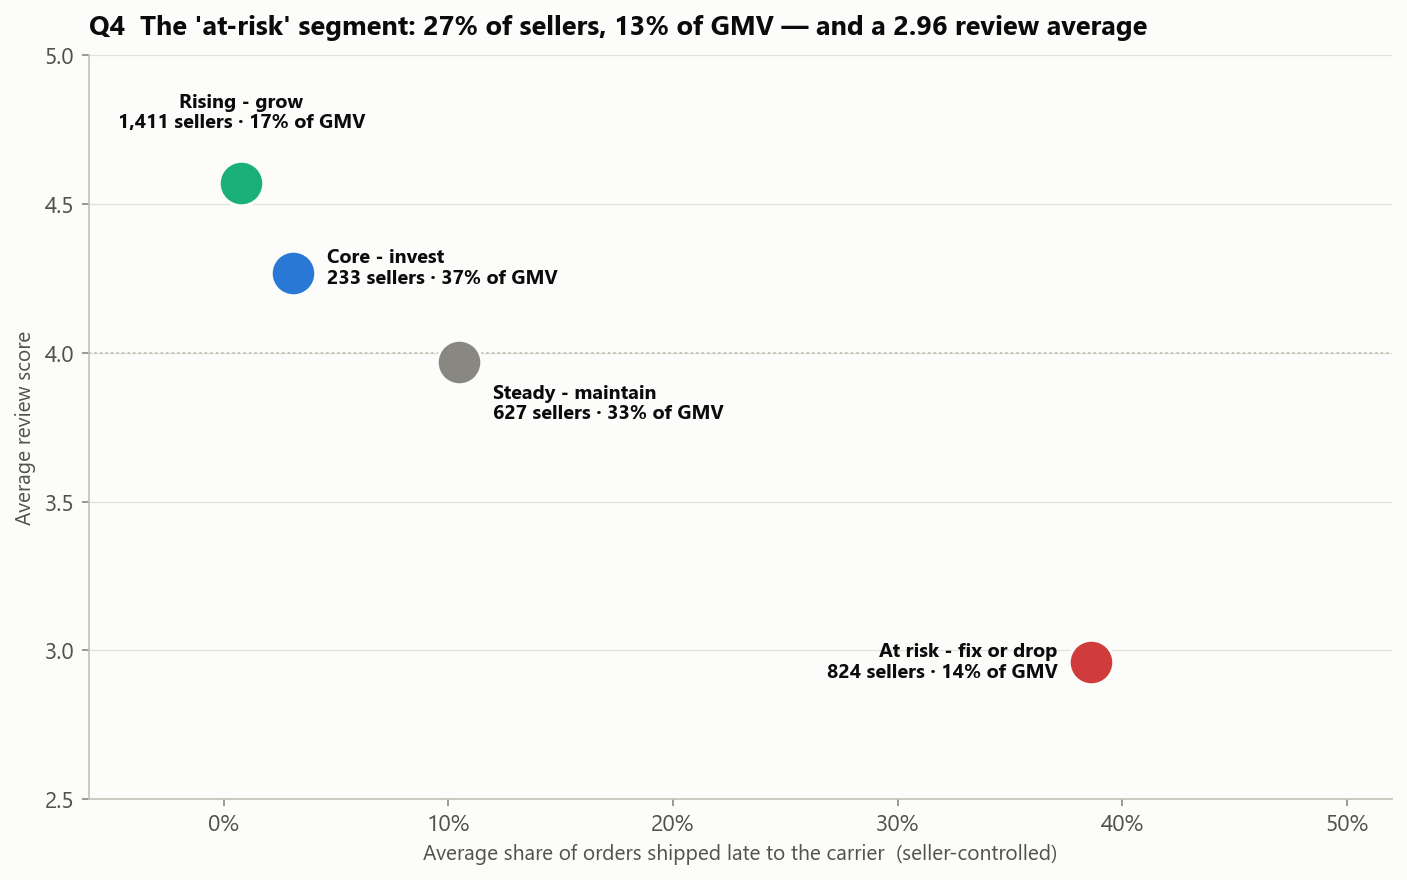

In [14]:
chart(plots.plot_q4_seller_segments(q4))

In [15]:
q4_sellers = run_sql_file("04_seller_scored"); q4_sellers.head()

,seller_id,orders,gmv,pct_shipped_late,avg_days_vs_estimate,avg_review_score,n_reviews,segment
0,4869f7a5dfa277a7dca6462dcf3b52b2,1132,229472.63,0.055,-11.10,4.133,1124,Core - invest
1,53243585a1d6dc2643021fd1853d8905,358,222776.05,0.068,-11.48,4.132,356,Core - invest
2,4a3ca9315b744ce9f8e9374361493884,1806,200472.92,0.087,-9.53,3.828,1785,Steady - maintain
3,fa1c13f2614d7b5c4749cbc52fecda94,585,194042.03,0.081,-10.31,4.339,581,Core - invest
4,7c67e1448b00f6e969d365cea6b010ab,982,187923.89,0.296,-11.38,3.489,976,At risk - fix or drop


**Number.**

| Segment | Sellers | % of GMV | Ship late | Avg review |
|---|--:|--:|--:|--:|
| Core — invest | 233 | 37% | 3% | 4.27 |
| Steady — maintain | 627 | 33% | 11% | 3.97 |
| Rising — grow | 1,411 | 17% | **1%** | **4.57** |
| **At risk — fix or drop** | **824** | **13%** | **39%** | **2.96** |

**Decision.** The **824 at-risk sellers are 27% of the seller base and generate 13% of
GMV, but blow their shipping SLA 39% of the time and average a 2.96 review.** They are a
reputational liability out of all proportion to their revenue. Put them on a
probation programme (enforced handover SLA, capped listings) and delist the ones that
don't move — the 13% GMV hit is short-term and partly recaptured by better-performing
sellers. Meanwhile **"Rising" (1,411 small sellers) ship better than Core and review
higher** — they are the pipeline; funnel search placement and onboarding support to them,
not to squeezing more from the 233 Core sellers.

---
## Q5. Revenue and order seasonality — growth trend and anomalies

In [16]:
q5 = show("05_revenue_seasonality"); q5

-- ============================================================================
-- 05_revenue_seasonality.sql
--
-- BUSINESS QUESTION
--   What do revenue and order volume look like month over month - the growth
--   trend, the seasonal shape, and any anomalies that distort the picture?
--
-- WHY IT MATTERS
--   Every downstream number (repeat rate, category mix, seller cohorts) is read
--   against this baseline. Anyone quoting "GMP grew X%" needs to know which
--   months are real and which are data artefacts.
--
-- WHAT THIS QUERY RETURNS  (one row per calendar month)
--   orders, revenue, avg_order_value
--   revenue_mom_pct              - month-over-month growth
--   revenue_index_vs_2017_01     - revenue relative to Jan 2017 = 100
--   is_partial_month             - flagged coverage problem (see below)
--
-- DATA-QUALITY DECISIONS  (full write-up in README > Data quality)
--   * Revenue = sum(item price + freight) from stg_order_value, by
--     order_purchase_timestamp month.
--

,month,orders,revenue,avg_order_value,revenue_mom_pct,revenue_index_vs_2017_01,is_partial_month
0,2016-09-01,2,279.69,139.85,NaN,0.0,True
1,2016-10-01,290,51354.52,177.08,18261.2,38.0,True
2,2016-12-01,1,19.62,19.62,-100.0,0.0,True
3,2017-01-01,787,136943.46,174.01,697878.9,100.0,False
4,2017-02-01,1718,283561.69,165.05,107.1,207.0,False
5,2017-03-01,2617,425617.96,162.64,50.1,311.0,False
6,2017-04-01,2377,405848.61,170.74,-4.6,296.0,False
7,2017-05-01,3640,582710.83,160.09,43.6,426.0,False
8,2017-06-01,3205,499652.24,155.90,-14.3,365.0,False
9,2017-07-01,3946,578753.73,146.67,15.8,423.0,False


  wrote q5_seasonality.png


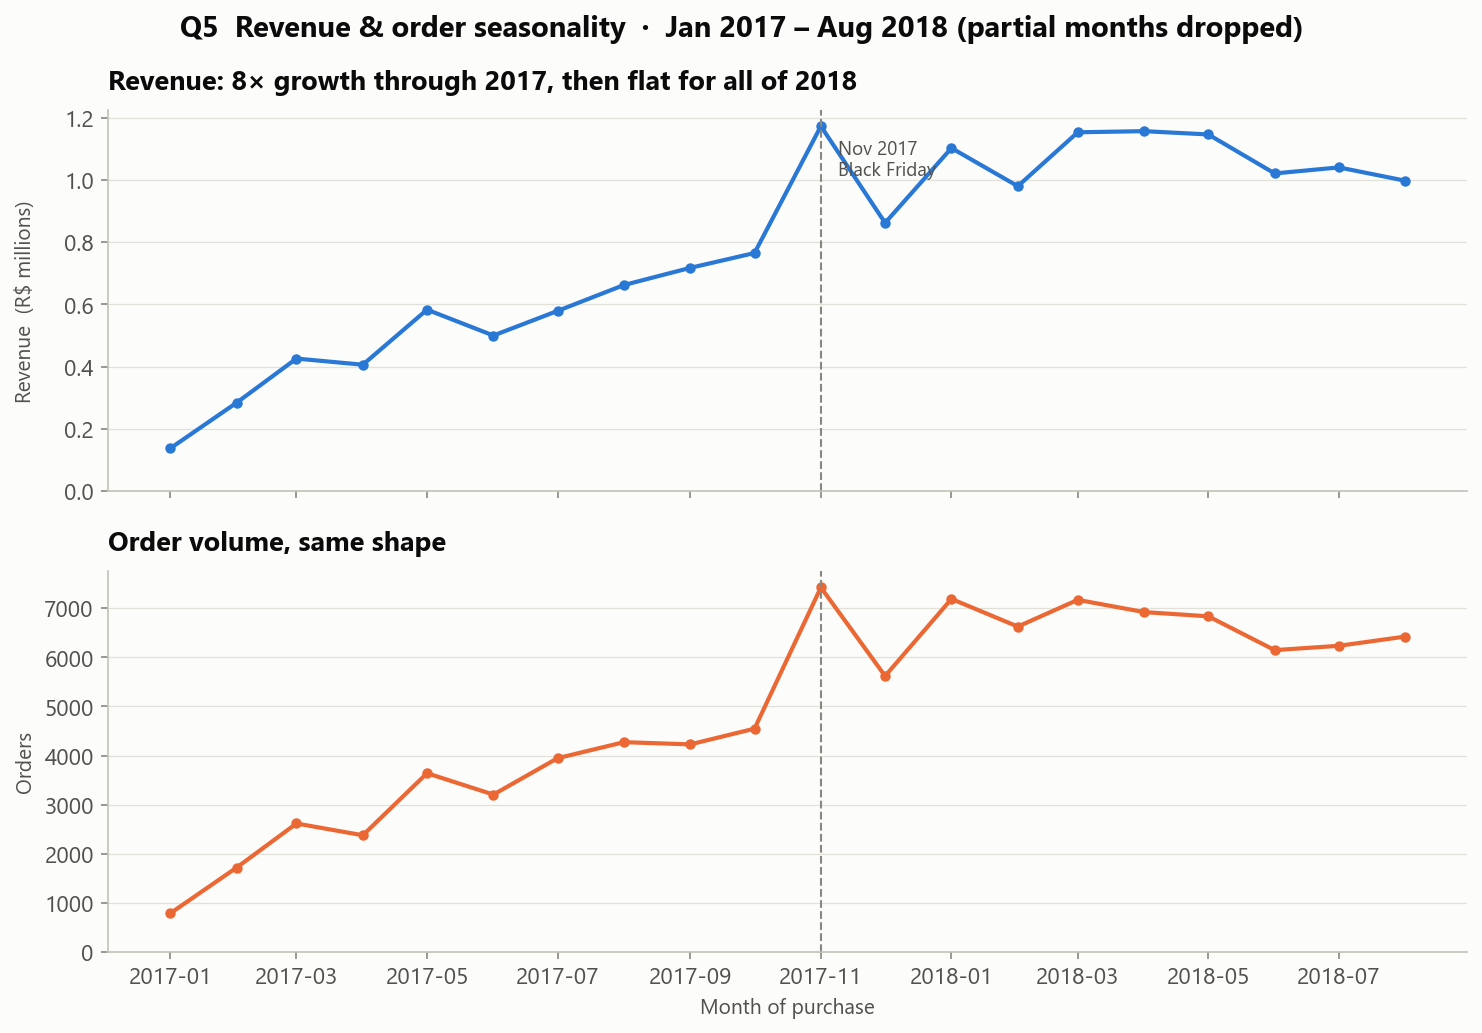

In [17]:
chart(plots.plot_q5_seasonality(q5))

In [18]:
q5a = show("05_revenue_daily_anomalies"); q5a

-- ============================================================================
-- 05_revenue_daily_anomalies.sql
--
-- Companion to 05_revenue_seasonality.sql. Flags individual days whose order
-- count is a >= 3-sigma outlier from the daily mean, so the monthly trend can be
-- read knowing which spikes are single events (Black Friday) rather than a
-- shift in the run rate.
--
-- WHAT THIS QUERY RETURNS  (one row per anomalous day, biggest first)
--   day, orders, revenue
--   orders_z        - standard deviations above/below the daily mean
--   note            - best-guess label for known Brazilian retail dates
--
-- DATA QUALITY: same status filter as the monthly query. The near-empty 2016
-- pilot days are excluded from the mean/sigma (day >= 2017-01-01) so they do
-- not deflate the baseline.
-- ============================================================================

WITH daily AS (
    SELECT
        o.order_purchase_timestamp::date          AS day,
        count(DISTINCT o

,day,orders,revenue,orders_z,note
0,2017-11-24,1166,178377.63,11.2,Black Friday 2017
1,2017-11-25,498,71858.16,3.7,Black Friday 2017


**Number.** Usable history is **Jan 2017 – Aug 2018** (2016 is a ~300-order pilot; the
last month is truncated). Revenue grew **~8×** through 2017 (R$137k in Jan 2017 to
R$1.17M in Nov 2017), then **went flat for the whole of 2018** — every month R$1.0–1.16M,
drifting *down* in H2. Average order value never moved: ~R$155–170 the entire time, so
growth was pure volume.

Only **two** days in 20 months are 3-sigma order-count outliers, and both are **Black
Friday 2017** (24 Nov: 1,166 orders, +11σ, R$178k in one day). There is no other
seasonal spike of note and no weekly-level anomaly at this grain.

**Decision.** The 2017 acquisition engine stalled in 2018 — that, not seasonality, is the
headline. Combined with Q3 (no repeat purchases), **flat acquisition = flat business**,
so the growth question is "why did new-customer acquisition plateau" and it needs its own
investigation. Black Friday is captured as a one-day event but produces no sustained
lift — the marketing spend around it is buying orders, not customers.

---
## Q6. Does seller↔customer distance explain delivery delays, or is it something else?

Distance is the haversine between the median coordinates of the seller's and customer's
zip prefixes.

In [19]:
q6 = show("06_geo_distance_vs_delay"); q6

-- ============================================================================
-- 06_geo_distance_vs_delay.sql
--
-- BUSINESS QUESTION
--   Does the physical distance between seller and customer explain slow / late
--   deliveries, or is something else driving them?
--
-- WHY IT MATTERS
--   If distance is the driver, the fix is logistics network design (regional
--   warehouses, closer sellers for far customers). If distance is already
--   priced into the estimate and orders are still late, the fix is upstream:
--   seller handover time or carrier performance. Same symptom, opposite
--   response - see also 06_geo_distance_correlation.sql.
--
-- WHAT THIS QUERY RETURNS  (one row per distance band)
--   orders, avg_distance_km
--   avg_delivery_days         - purchase -> customer
--   avg_days_vs_estimate      - actual - promised (does the promise scale
--                               with distance the way transit time does?)
--   avg_seller_handover_days  - purchase -> carrier pick

,distance_band,orders,avg_distance_km,avg_delivery_days,avg_days_vs_estimate,avg_seller_handover_days,pct_late
0,a) 0-100 km,17795,40.0,6.5,-9.5,3.2,0.064
1,b) 100-300 km,13314,200.0,9.9,-11.5,3.2,0.064
2,c) 300-700 km,36228,459.0,12.8,-12.4,3.2,0.080
3,d) 700-1500 km,19866,966.0,15.4,-13.0,3.3,0.087
4,e) 1500-2500 km,7914,2043.0,20.2,-12.5,3.4,0.132
5,f) 2500+ km,876,2756.0,23.3,-15.4,3.7,0.115


In [20]:
q6c = show("06_geo_distance_correlation"); q6c

-- ============================================================================
-- 06_geo_distance_correlation.sql
--
-- The one-number version of question 6. Two correlations decide the story:
--
--   corr(distance, delivery_days)     - does it take longer to ship far? (expect yes)
--   corr(distance, days_vs_estimate)  - is it LATER vs the promise when far?
--
-- If the first is strong and the second is near zero, Olist's estimated
-- delivery date already absorbs distance, and lateness is coming from
-- somewhere else (seller handover, carrier reliability) - so the correlation
-- of handover time with lateness is reported alongside for comparison.
--
-- RETURNS one row:
--   n_orders
--   r_distance_delivery, r_distance_vs_estimate
--   r_handover_vs_estimate       - corr(seller_handover_days, days_vs_estimate)
--   slope_days_per_1000km        - OLS: extra transit days per 1,000 km
--
-- Same geo build and filters as 06_geo_distance_vs_delay.sql.
-- ================================

,n_orders,r_distance_delivery,r_distance_vs_estimate,r_handover_vs_estimate,slope_days_per_1000km
0,95992,0.392,-0.077,0.196,6.33


In [21]:
q6s = show("06_geo_delay_by_state"); q6s

-- ============================================================================
-- 06_geo_delay_by_state.sql
--
-- Question 6 broken out by the customer's state. Brazil's regional inequality
-- shows up hard in logistics: the South/Southeast (where Olist's sellers
-- cluster) vs the North/Northeast.
--
-- WHAT THIS QUERY RETURNS  (one row per customer_state)
--   orders, avg_distance_km
--   avg_delivery_days, avg_days_vs_estimate, pct_late
--   avg_seller_handover_days
--   avg_estimate_window_days  - promised window the customer was shown
--                               (purchase -> estimated date). Does Olist widen
--                               the promise for far states, and by enough?
--
-- Same geo build / filters as 06_geo_distance_vs_delay.sql. States with
-- < 100 delivered orders are kept but are noise - flagged low_sample.
-- ============================================================================

WITH order_seller_geo AS (
    SELECT
        o.order_id,
        cus

,customer_state,orders,avg_distance_km,avg_delivery_days,avg_estimate_window_days,avg_days_vs_estimate,pct_late,avg_seller_handover_days,low_sample
0,AL,396,1834.0,24.5,33.2,-8.7,0.240,3.5,False
1,MA,713,2106.0,21.4,31.1,-9.6,0.195,3.6,False
2,SE,334,1650.0,21.5,31.4,-10.0,0.153,3.6,False
3,ES,1984,803.0,15.7,26.2,-10.5,0.121,3.4,False
4,BA,3238,1346.0,19.3,30.1,-10.8,0.139,3.3,False
5,CE,1272,2188.0,21.2,32.0,-10.8,0.154,3.3,False
6,SP,40406,251.0,8.7,19.8,-11.1,0.059,3.2,False
7,MS,699,846.0,15.5,26.6,-11.1,0.114,3.2,False
8,PI,473,1958.0,19.4,30.7,-11.3,0.159,3.2,False
9,SC,3537,573.0,14.9,26.4,-11.5,0.097,3.3,False


  wrote q6_distance.png


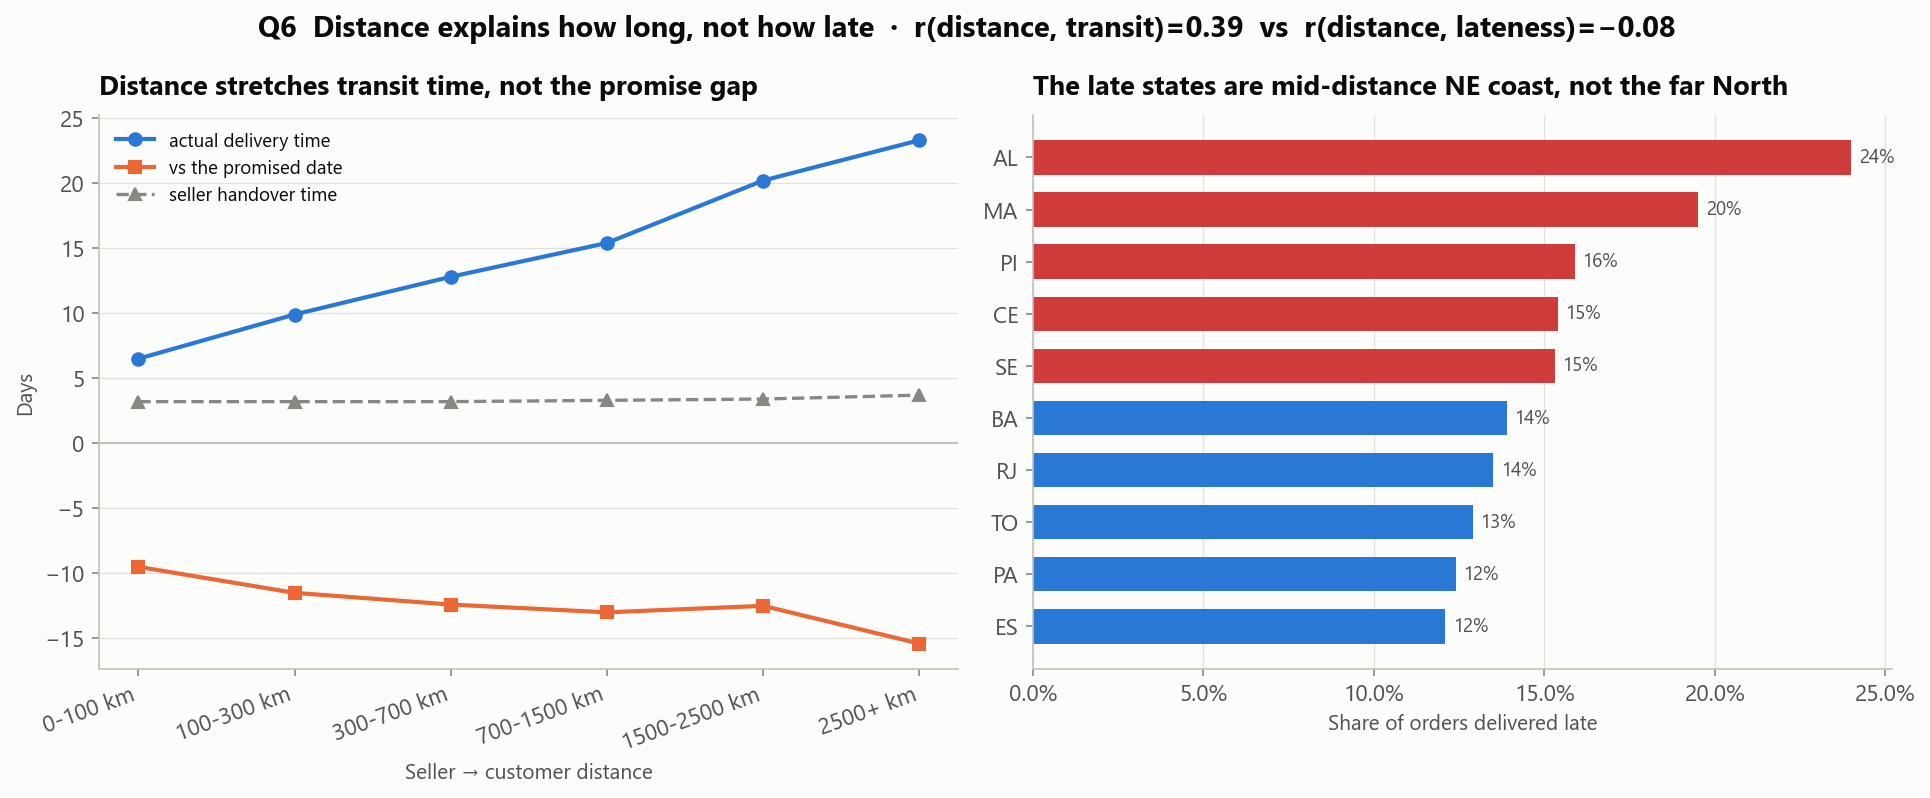

In [22]:
chart(plots.plot_q6_distance(q6, q6s))

**Number.** Distance strongly predicts **transit time** — *r* = **0.39**, about **6 extra
days per 1,000 km**. It does **not** predict **lateness against the promise** — *r* =
**−0.08**, essentially zero, because Olist's estimate already scales with distance (the
promised window goes from ~20 days for São Paulo to 40–47 days for the Amazon states, and
those far customers then beat it by 17–20 days). Seller **handover time** correlates with
lateness about 2.5× more strongly than distance does (*r* = 0.20 vs −0.08).

The genuinely late states are not the far ones — they are the **mid-distance Northeast
coast**: Alagoas **24% late**, Maranhão 20%, Piauí 16%, Ceará and Sergipe ~15%, versus
São Paulo at 6%. Alagoas sits ~1,800 km out but gets only a ~33-day promised window
against ~25-day actual delivery with high variance.

**Decision.** Distance is not the lever — don't build regional warehouses for Manaus,
those customers are already delighted. Two real levers: (1) **seller handover time** is
the strongest controllable predictor of missing the promise — enforce it (ties to Q4).
(2) **Widen the estimated-delivery window for the Northeast coastal states (AL, MA, PI,
CE, SE) by ~5–7 days**, or fix the specific carrier lanes serving them; today the promise
there is set too tight for the actual variance.

---
## Limitations

- **Correlation, not causation.** Late delivery co-occurs with damaged goods, remote
  regions, low-rated sellers and cheap freight choices. Q1's −0.33 is an association; the
  true causal effect of a day's delay is not identified here.
- **The data ends in October 2018.** The 2018 growth plateau (Q5) and the low repeat rate
  (Q3) are both partly censoring — a customer who bought in August 2018 had weeks, not
  years, to come back. The 120-day window in Q3 mitigates but does not remove this.
- **Small samples.** Q2 drops categories under 200 orders, but several of the 43 that
  remain (`audio` 345, `drinks` 287) still carry wide error bars on the on-time/late
  split. Q6's far-North states have 40–240 orders each.
- **"Olist" is not a consumer brand.** It sells through many storefronts; a customer may
  not know they are buying "on Olist", which depresses measured repeat behaviour in Q3.
- **`customer_unique_id`** is Olist's own identity resolution; its accuracy bounds Q3.
- **One country, one platform, 2016–2018.** None of this generalises to other markets or
  to the post-2018 Brazilian logistics network.

---
## Summary — six questions, six decisions

1. **Missing the promised delivery date is a cliff, not a slope** — a single day late
   costs a full star and triples the 1-star rate. Trigger intervention *before* the date
   passes.
2. **Worst categories ≠ biggest categories.** Fix `audio`/`electronics` lanes; attack the
   late *rate* in health/beauty and bed/bath where the volume is.
3. **97% of customers never return, and a bad first order barely changes that** — justify
   delivery investment on first-order reputation, not LTV.
4. **824 at-risk sellers: 13% of GMV, 39% late, 2.96 stars** — probation-or-drop; grow
   the 1,411 "Rising" sellers who already outperform Core.
5. **Growth stalled through all of 2018** — a plateau, not a season; acquisition needs
   its own diagnosis.
6. **Distance sets how *long*, not how *late*** — the levers are seller handover time and
   a wider promised window for the Northeast coast, not warehouses.